Train: 38624 | Val: 5624 | Test: 10934 | Total: 55182

CLASS DISTRIBUTION (TRAIN)
  infrastructure_and_utility_damage: 5715 (14.8%)
  injured_or_dead_people: 5110 (13.2%)
  not_humanitarian: 4407 (11.4%)
  other_relevant_information: 8501 (22.0%)
  rescue_volunteering_or_donation_effort: 14891 (38.6%)
Imbalance ratio: 3.4:1

TWEET LENGTH (TRAIN)
  Mean: 21.53 | Median: 19 | Max: 60 | Min: 3
  Tweets > 128 tokens: 0

LOW INFO TWEETS: 0 (0.0%)

CLASS WEIGHTS
  infrastructure_and_utility_damage: 1.1183
  injured_or_dead_people: 1.2506
  not_humanitarian: 1.4502
  other_relevant_information: 0.7518
  rescue_volunteering_or_donation_effort: 0.4292

Class                                            Train      Val     Test
---------------------------------------------------------------------------
infrastructure_and_utility_damage                 5715      830     1617
injured_or_dead_people                            5110      746     1447
not_humanitarian                                  440

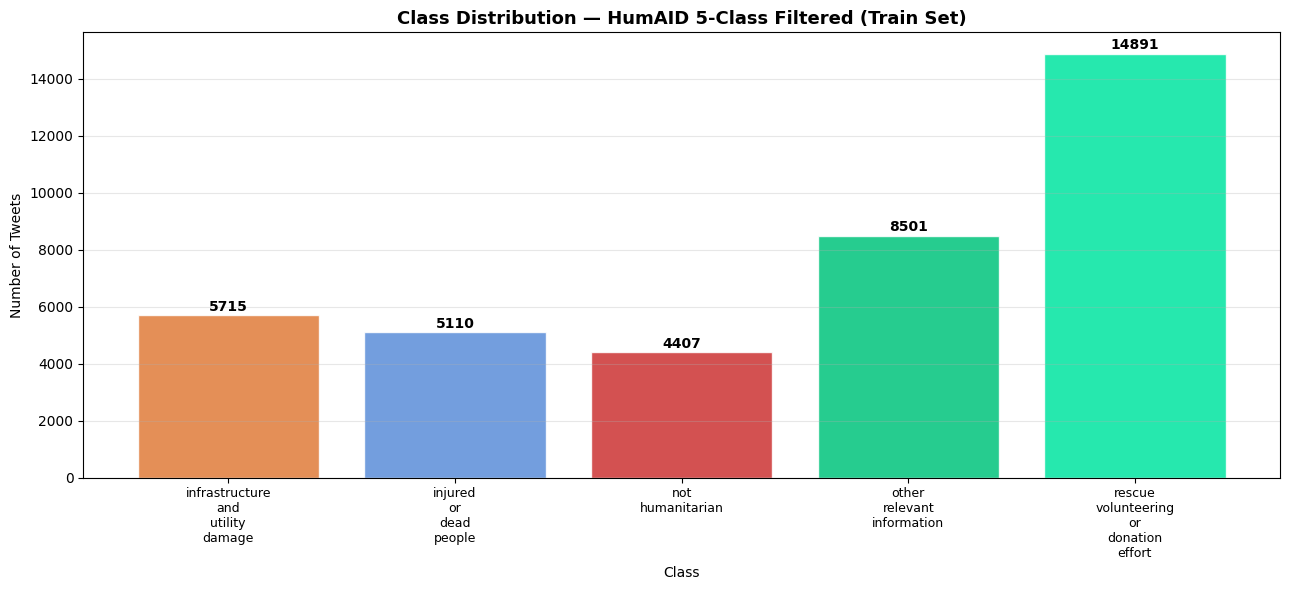

Saved: class_distribution.png


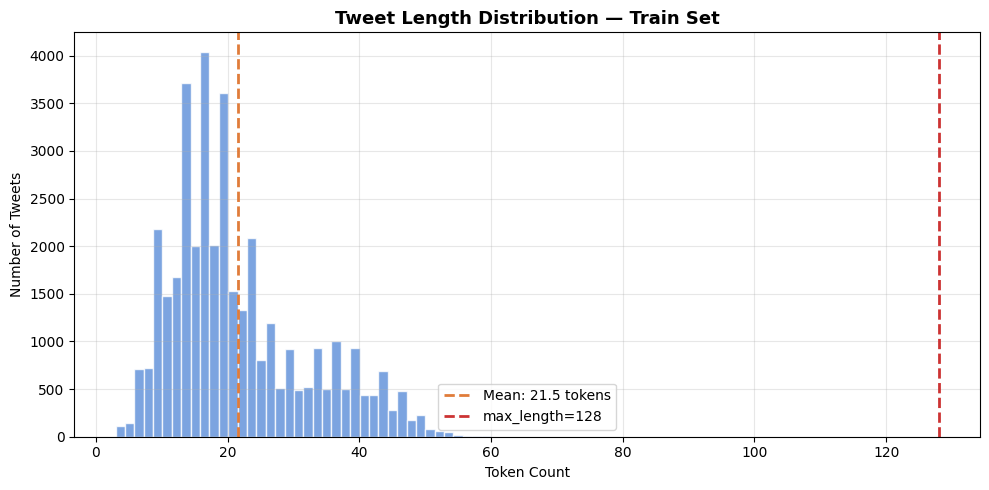

Saved: tweet_length.png


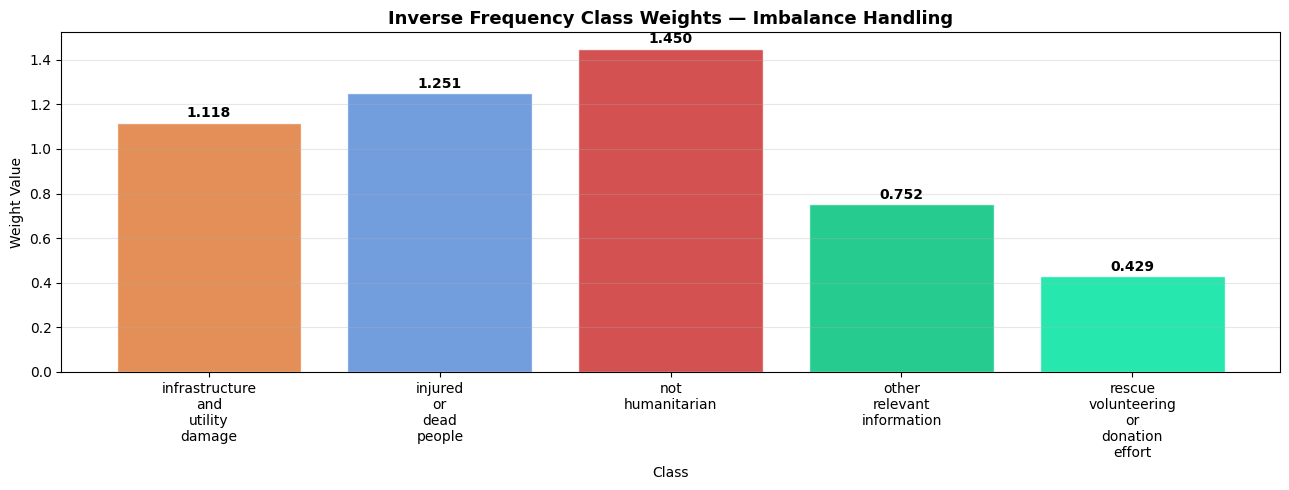

Saved: class_weights.png


In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import torch

train = pd.read_parquet("/content/train.parquet")
val   = pd.read_parquet("/content/val.parquet")
test  = pd.read_parquet("/content/test.parquet")

with open("/content/label_mapping.json") as f:
    mapping = json.load(f)

id2label = mapping["id2label"]  # already string keys — no conversion needed

# ── Stats ─────────────────────────────────────────────────────────────────────
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)} | Total: {len(train)+len(val)+len(test)}")

print("\nCLASS DISTRIBUTION (TRAIN)")
label_counts = train['label'].value_counts().sort_index()
for lid, count in label_counts.items():
    print(f"  {id2label[lid]}: {count} ({count/len(train)*100:.1f}%)")
print(f"Imbalance ratio: {label_counts.max()/label_counts.min():.1f}:1")

print("\nTWEET LENGTH (TRAIN)")
train['token_count'] = train['tweet_text'].str.split().str.len()
print(f"  Mean: {train['token_count'].mean():.2f} | Median: {train['token_count'].median():.0f} | Max: {train['token_count'].max()} | Min: {train['token_count'].min()}")
print(f"  Tweets > 128 tokens: {(train['token_count']>128).sum()}")

if 'low_info' in train.columns:
    print(f"\nLOW INFO TWEETS: {train['low_info'].sum()} ({train['low_info'].mean()*100:.1f}%)")

print("\nCLASS WEIGHTS")
weights = torch.load("/content/class_weights.pt", map_location='cpu')
for i, w in enumerate(weights.tolist()):
    print(f"  {id2label[str(i)]}: {w:.4f}")

print(f"\n{'Class':<45} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-"*75)
for k in sorted(id2label.keys()):
    tr = (train['label']==k).sum()
    v  = (val['label']==k).sum()
    te = (test['label']==k).sum()
    print(f"{id2label[k]:<45} {tr:>8} {v:>8} {te:>8}")
print(f"{'TOTAL':<45} {len(train):>8} {len(val):>8} {len(test):>8}")

# ── Plot 1: Class Distribution ────────────────────────────────────────────────
colors = ['#e07c3a','#5b8dd9','#cc3333','#00c47c','#00e5a0']
keys   = sorted(id2label.keys())
names  = [id2label[k].replace("_","\n") for k in keys]
counts = [(train['label']==k).sum() for k in keys]

fig, ax = plt.subplots(figsize=(13,6))
bars = ax.bar(names, counts, color=colors, alpha=0.85, edgecolor='white')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            str(c), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title("Class Distribution — HumAID 5-Class Filtered (Train Set)", fontweight='bold', fontsize=13)
ax.set_ylabel("Number of Tweets")
ax.set_xlabel("Class")
ax.tick_params(axis='x', labelsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

# ── Plot 2: Tweet Length ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(train['token_count'], bins=40, color='#5b8dd9', alpha=0.8, edgecolor='white')
ax.axvline(train['token_count'].mean(), color='#e07c3a', linestyle='--', linewidth=2,
           label=f"Mean: {train['token_count'].mean():.1f} tokens")
ax.axvline(128, color='#cc3333', linestyle='--', linewidth=2, label='max_length=128')
ax.set_title("Tweet Length Distribution — Train Set", fontweight='bold', fontsize=13)
ax.set_xlabel("Token Count")
ax.set_ylabel("Number of Tweets")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/tweet_length.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tweet_length.png")

# ── Plot 3: Class Weights ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13,5))
wlabels = [id2label[str(i)].replace("_","\n") for i in range(len(weights))]
wvals   = weights.tolist()
bars = ax.bar(wlabels, wvals, color=colors, alpha=0.85, edgecolor='white')
for bar, w in zip(bars, wvals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{w:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title("Inverse Frequency Class Weights — Imbalance Handling", fontweight='bold', fontsize=13)
ax.set_ylabel("Weight Value")
ax.set_xlabel("Class")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/class_weights.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_weights.png")